In [1]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import Modules.analysis as analysis

In [2]:
sims_dir = '/home/drfrbc/Neural-Modeling/simulations/2025-07-25-11-45-all_inh_rhythmic_depth_sweep_lower' # folder containing simulation folders

sim_dirs = [os.path.join(sims_dir, sim_dir) for sim_dir in os.listdir(sims_dir)] # every directory in sims_dir

In [3]:
# gather spike tables into 1.

import os
import pandas as pd

# Suppose sim_dirs is your list of simulation directories
# import your analysis module
import Modules.analysis as analysis

# Accumulate data in a list of rows
all_rows = []

for sim_dir in sim_dirs:
    # Read dSpike_table.csv
    dSpike_path = os.path.join(sim_dir, "dSpike_table.csv")
    if not os.path.exists(dSpike_path):
        print(f"Skipping {sim_dir}, {dSpike_path} not found.")
        continue
    df = pd.read_csv(dSpike_path)
    
    # Get CI_amplitude from parameters
    try:
        params = analysis.DataReader.load_parameters(sim_dir)
        CI_amplitude = params.h_i_amplitude
        perisomatic_rhythmic_depth = params.inh_syn_properties['perisomatic']['rhythmic_depth']
        distal_rhythmic_depth = params.inh_syn_properties['distal_basal']['rhythmic_depth']
    except Exception as e:
        print(f"Error loading parameters from {sim_dir}: {e}")
        CI_amplitude = None

    # Add sim_dir and CI_amplitude columns
    df['sim_dir'] = sim_dir
    df['CI_amplitude'] = CI_amplitude
    df['np_seed'] = params.numpy_random_state if hasattr(params, 'numpy_random_state') else None
    df['perisomatic_rhythmic_depth'] = perisomatic_rhythmic_depth
    df['distal_rhythmic_depth'] = distal_rhythmic_depth

    # Append to master list
    all_rows.append(df)

# Combine all rows into one DataFrame
all_data = pd.concat(all_rows, ignore_index=True)


--No graphics will be displayed.


Skipping /home/drfrbc/Neural-Modeling/simulations/2025-07-25-11-45-all_inh_rhythmic_depth_sweep_lower/Soma and Ca2+ FR_I.png, /home/drfrbc/Neural-Modeling/simulations/2025-07-25-11-45-all_inh_rhythmic_depth_sweep_lower/Soma and Ca2+ FR_I.png/dSpike_table.csv not found.


In [4]:
all_data

,Unnamed: 0,Segment_Type,Total_NMDA_Spikes,Total_NA_Spikes,Total_CA_Spikes,Soma_Spike_Rate,sim_dir,CI_amplitude,np_seed,perisomatic_rhythmic_depth,distal_rhythmic_depth
0,0,apic,3991.9,11.2,10.6,0.166667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,5000,0.00,0.00
1,1,dend,3481.3,14.9,0.0,0.166667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,5000,0.00,0.00
2,0,apic,3661.1,7.9,41.3,0.533333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,93486590,0.00,0.00
3,1,dend,3704.5,14.4,0.0,0.533333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,93486590,0.00,0.00
4,0,apic,3658.0,9.5,9.7,0.633333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,12378,0.00,0.00
5,1,dend,3764.4,10.6,0.0,0.633333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,12378,0.00,0.00
6,0,apic,3652.2,10.1,16.4,0.166667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,123456789,0.00,0.00
7,1,dend,3637.0,11.6,0.0,0.166667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,123456789,0.00,0.00
8,0,apic,3679.4,11.3,9.6,0.566667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,987654321,0.00,0.00
9,1,dend,3647.5,17.8,0.0,0.566667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,987654321,0.00,0.00


In [5]:
apical_data = all_data[all_data['Segment_Type'] == 'apic']

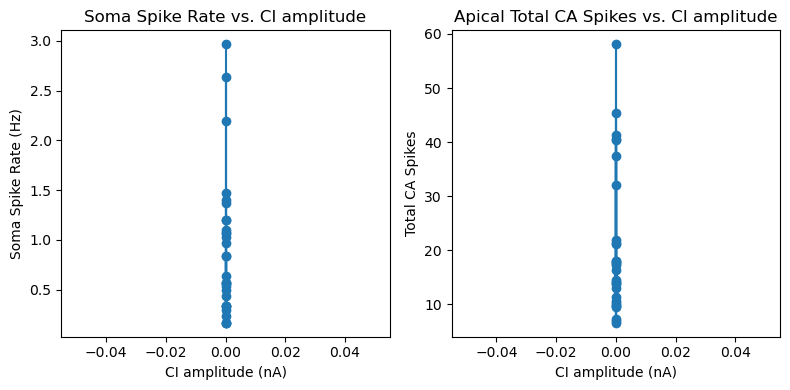

In [6]:
import matplotlib.pyplot as plt

# Scatter plot: CI_amplitude vs. Soma_Spike_Rate
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(apical_data['CI_amplitude'], apical_data['Soma_Spike_Rate'])
plt.scatter(apical_data['CI_amplitude'], apical_data['Soma_Spike_Rate'])
plt.xlabel('CI amplitude (nA)')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. CI amplitude')
# plt.savefig(os.path.join(sims_dir, 'Soma FR/I.png')) # don't need because it is one figure.

# Scatter plot: CI_amplitude vs. Total_CA_Spikes
plt.subplot(1, 2, 2)
plt.plot(apical_data['CI_amplitude'], apical_data['Total_CA_Spikes'])
plt.scatter(apical_data['CI_amplitude'], apical_data['Total_CA_Spikes'])
plt.xlabel('CI amplitude (nA)')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. CI amplitude')
plt.savefig(os.path.join(sims_dir, 'Soma and Ca2+ FR_I.png'))

plt.tight_layout()
plt.show()

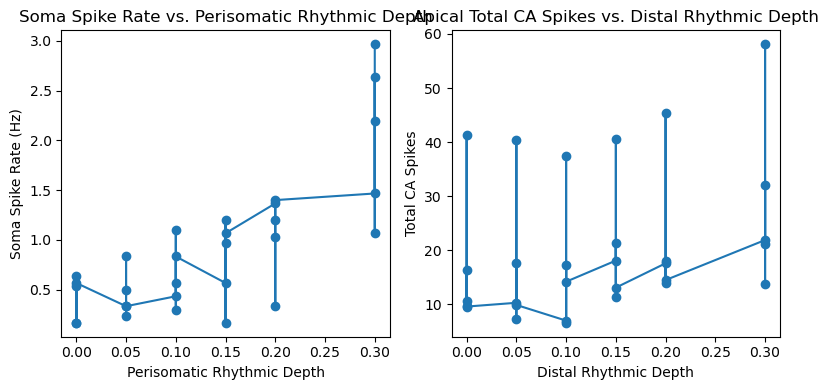

In [7]:
import matplotlib.pyplot as plt

# Scatter plot: CI_amplitude vs. Soma_Spike_Rate
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(apical_data['perisomatic_rhythmic_depth'], apical_data['Soma_Spike_Rate'])
plt.scatter(apical_data['perisomatic_rhythmic_depth'], apical_data['Soma_Spike_Rate'])
plt.xlabel('Perisomatic Rhythmic Depth')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. Perisomatic Rhythmic Depth')
# plt.savefig(os.path.join(sims_dir, 'Soma FR/I.png')) # don't need because it is one figure.

# Scatter plot: CI_amplitude vs. Total_CA_Spikes
plt.subplot(1, 2, 2)
plt.plot(apical_data['distal_rhythmic_depth'], apical_data['Total_CA_Spikes'])
plt.scatter(apical_data['distal_rhythmic_depth'], apical_data['Total_CA_Spikes'])
plt.xlabel('Distal Rhythmic Depth')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. Distal Rhythmic Depth')
plt.savefig(os.path.join(sims_dir, 'Soma and Ca2+ FR_I.png'))

plt.tight_layout()
plt.show()

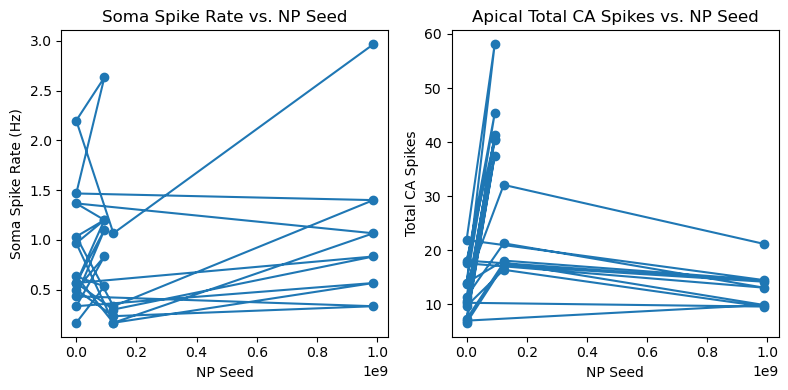

In [8]:
import matplotlib.pyplot as plt

# Scatter plot: CI_amplitude vs. Soma_Spike_Rate
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(apical_data['np_seed'], apical_data['Soma_Spike_Rate'])
plt.scatter(apical_data['np_seed'], apical_data['Soma_Spike_Rate'])
plt.xlabel('NP Seed')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. NP Seed')
# plt.savefig(os.path.join(sims_dir, 'Soma FR/I.png')) # don't need because it is one figure.

# Scatter plot: CI_amplitude vs. Total_CA_Spikes
plt.subplot(1, 2, 2)
plt.plot(apical_data['np_seed'], apical_data['Total_CA_Spikes'])
plt.scatter(apical_data['np_seed'], apical_data['Total_CA_Spikes'])
plt.xlabel('NP Seed')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. NP Seed')
plt.savefig(os.path.join(sims_dir, 'Soma and Ca2+ FR_I.png'))

plt.tight_layout()
plt.show()

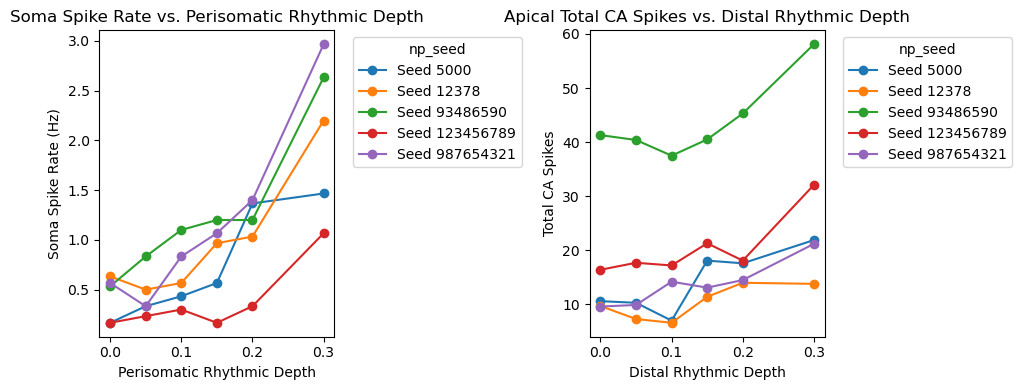

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Example: apical_data is a DataFrame with columns: 'np_seed', 'perisomatic_rhythmic_depth', 'distal_rhythmic_depth', 'Soma_Spike_Rate', 'Total_CA_Spikes'

# 1. Plot Soma_Spike_Rate vs. Perisomatic Rhythmic Depth, one line per np_seed
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)

for seed, group in apical_data.groupby('np_seed'):
    # Sort by depth for a clean line
    group_sorted = group.sort_values('perisomatic_rhythmic_depth')
    plt.plot(group_sorted['perisomatic_rhythmic_depth'],
             group_sorted['Soma_Spike_Rate'],
             label=f'Seed {seed}', marker='o')

plt.xlabel('Perisomatic Rhythmic Depth')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. Perisomatic Rhythmic Depth')
plt.legend(title='np_seed', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Plot Total_CA_Spikes vs. Distal Rhythmic Depth, one line per np_seed
plt.subplot(1, 2, 2)

for seed, group in apical_data.groupby('np_seed'):
    group_sorted = group.sort_values('distal_rhythmic_depth')
    plt.plot(group_sorted['distal_rhythmic_depth'],
             group_sorted['Total_CA_Spikes'],
             label=f'Seed {seed}', marker='o')

plt.xlabel('Distal Rhythmic Depth')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. Distal Rhythmic Depth')
plt.legend(title='np_seed', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


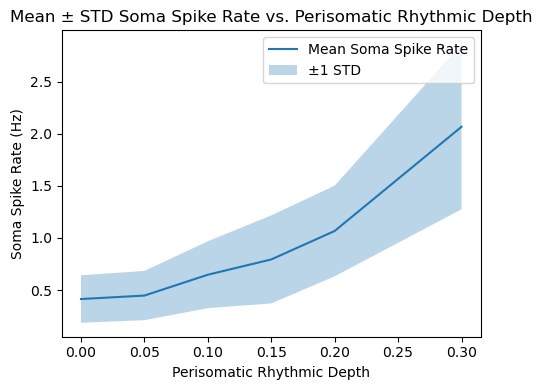

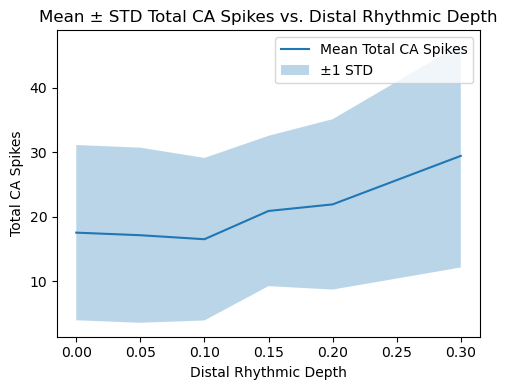

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# For Soma_Spike_Rate vs Perisomatic Rhythmic Depth
depths = np.sort(apical_data['perisomatic_rhythmic_depth'].unique())
means = []
stds = []

for depth in depths:
    vals = apical_data.loc[apical_data['perisomatic_rhythmic_depth'] == depth, 'Soma_Spike_Rate']
    means.append(vals.mean())
    stds.append(vals.std())

means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(5,4))
plt.plot(depths, means, label='Mean Soma Spike Rate')
plt.fill_between(depths, means-stds, means+stds, alpha=0.3, label='±1 STD')
plt.xlabel('Perisomatic Rhythmic Depth')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Mean ± STD Soma Spike Rate vs. Perisomatic Rhythmic Depth')
plt.legend()
plt.tight_layout()
plt.show()

# Repeat for Total_CA_Spikes vs Distal Rhythmic Depth:
depths = np.sort(apical_data['distal_rhythmic_depth'].unique())
means = []
stds = []

for depth in depths:
    vals = apical_data.loc[apical_data['distal_rhythmic_depth'] == depth, 'Total_CA_Spikes']
    means.append(vals.mean())
    stds.append(vals.std())

means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(5,4))
plt.plot(depths, means, label='Mean Total CA Spikes')
plt.fill_between(depths, means-stds, means+stds, alpha=0.3, label='±1 STD')
plt.xlabel('Distal Rhythmic Depth')
plt.ylabel('Total CA Spikes')
plt.title('Mean ± STD Total CA Spikes vs. Distal Rhythmic Depth')
plt.legend()
plt.tight_layout()
plt.show()
